# Python Data Analysis 
# 1997 Asian Financial Crisis : South Asia - Economic Development 
## QTM 350: Final Project
### Joe Xia

## Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv("../data/clean_wdi_data.csv")

print("Columns in dataset:")
print(df.columns.tolist())
df.head()

Columns in dataset:
['country_code', 'country_name', 'year', 'gdp_per_capita', 'gdp_growth_pct', 'employment_ratio', 'shock_period_flag']


,country_code,country_name,year,gdp_per_capita,gdp_growth_pct,employment_ratio,shock_period_flag
0,BGD,Bangladesh,1990,473.44,5.62,NaN,Normal
1,BGD,Bangladesh,1991,480.67,3.49,55.67,Normal
2,BGD,Bangladesh,1992,497.37,5.44,55.80,Normal
3,BGD,Bangladesh,1993,511.19,4.71,55.90,Normal
4,BGD,Bangladesh,1994,521.32,3.89,56.02,Normal


## Verify shock_period_flag for Asian Financial Crisis
Cross-check which years are labeled in the dataset to confirm our period classification aligns with the data.

In [2]:
crisis_flagged = df[df["shock_period_flag"] == "Asian Financial Crisis"]
print("Years flagged as Asian Financial Crisis in dataset:")
print(sorted(crisis_flagged["year"].unique()))
print("\nCountries flagged:")
print(sorted(crisis_flagged["country_name"].unique()))

Years flagged as Asian Financial Crisis in dataset:
[1997]

Countries flagged:
['Bangladesh', 'Bhutan', 'India', 'Maldives', 'Nepal', 'Pakistan', 'Sri Lanka']


## 1997 Asian Financial Crisis Data

The 1997 Asian Financial Crisis began in Thailand in July 1997 and spread across Southeast and South Asia through 1998 before recovery began in 1999. Unlike the 2008 and COVID crises which each have a single peak year, this crisis unfolded over two years (1997–1998), so both are classified as the Crisis period here.

In [3]:
# Years around the 1997 Asian Financial Crisis
df_1997 = df[(df["year"] >= 1994) & (df["year"] <= 2001)].copy()

# Classify periods
# Crisis spans 1997-1998 because the financial contagion persisted through both years
def classify_period(year):
    if year in [1994, 1995, 1996]:
        return "Pre-crisis"
    elif year in [1997, 1998]:
        return "Crisis"
    elif year in [1999, 2000, 2001]:
        return "Post-crisis"
    return np.nan

df_1997["period"] = df_1997["year"].apply(classify_period)

print(df_1997.head())
print("\nYears included:", sorted(df_1997["year"].unique()))
print("Countries included:", sorted(df_1997["country_name"].unique()))

  country_code country_name  year  gdp_per_capita  gdp_growth_pct  \
4          BGD   Bangladesh  1994          521.32            3.89   
5          BGD   Bangladesh  1995          537.93            5.12   
6          BGD   Bangladesh  1996          552.08            4.52   
7          BGD   Bangladesh  1997          566.27            4.49   
8          BGD   Bangladesh  1998          584.45            5.18   

   employment_ratio       shock_period_flag      period  
4             56.02                  Normal  Pre-crisis  
5             56.13                  Normal  Pre-crisis  
6             56.24                  Normal  Pre-crisis  
7             56.28  Asian Financial Crisis      Crisis  
8             56.29                  Normal      Crisis  

Years included: [1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001]
Countries included: ['Bangladesh', 'Bhutan', 'India', 'Maldives', 'Nepal', 'Pakistan', 'Sri Lanka']


## Summary Stats

In [4]:
print("Overall Summary Statistics (1994–2001)")
overall_summary = df_1997[["gdp_per_capita", "gdp_growth_pct", "employment_ratio"]].describe().round(2)
print(overall_summary)

print("\n Summary Statistics by Country")
country_summary = (
    df_1997.groupby("country_name")[["gdp_per_capita", "gdp_growth_pct", "employment_ratio"]]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)
print(country_summary)

print("\nSummary Statistics by Period ")
period_summary = (
    df_1997.groupby("period")[["gdp_per_capita", "gdp_growth_pct", "employment_ratio"]]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)
print(period_summary)

Overall Summary Statistics (1994–2001)
       gdp_per_capita  gdp_growth_pct  employment_ratio
count           56.00           56.00             56.00
mean          1715.86            5.18             52.73
std           1927.03            2.46              8.93
min            472.95           -3.94             37.01
25%            597.36            4.01             49.55
50%           1028.99            5.06             52.72
75%           1689.02            6.25             56.11
max           7037.09           12.99             69.29

 Summary Statistics by Country
             gdp_per_capita                                    gdp_growth_pct  \
                       mean   median     std      min      max           mean   
country_name                                                                    
Bangladesh           578.02   575.36   41.37   521.32   641.29           4.78   
Bhutan              1157.12  1160.70  119.93   963.02  1321.10           5.94   
India               

## Average values by country and period

Country and Period averages
   country_name       period  gdp_per_capita  gdp_growth_pct  employment_ratio
0    Bangladesh       Crisis          575.36            4.84             56.28
1    Bangladesh  Post-crisis          620.69            5.01             56.21
2    Bangladesh   Pre-crisis          537.11            4.51             56.13
3        Bhutan       Crisis         1160.70            5.64             69.17
4        Bhutan  Post-crisis         1276.45            6.22             68.73
5        Bhutan   Pre-crisis         1035.42            5.86             69.25
6         India       Crisis          681.44            5.12             54.74
7         India  Post-crisis          759.25            5.84             55.36
8         India   Pre-crisis          621.26            7.26             53.98
9      Maldives       Crisis         6427.32            7.94             52.33
10     Maldives  Post-crisis         6857.92            2.03             53.24
11     Maldives   Pre-cr

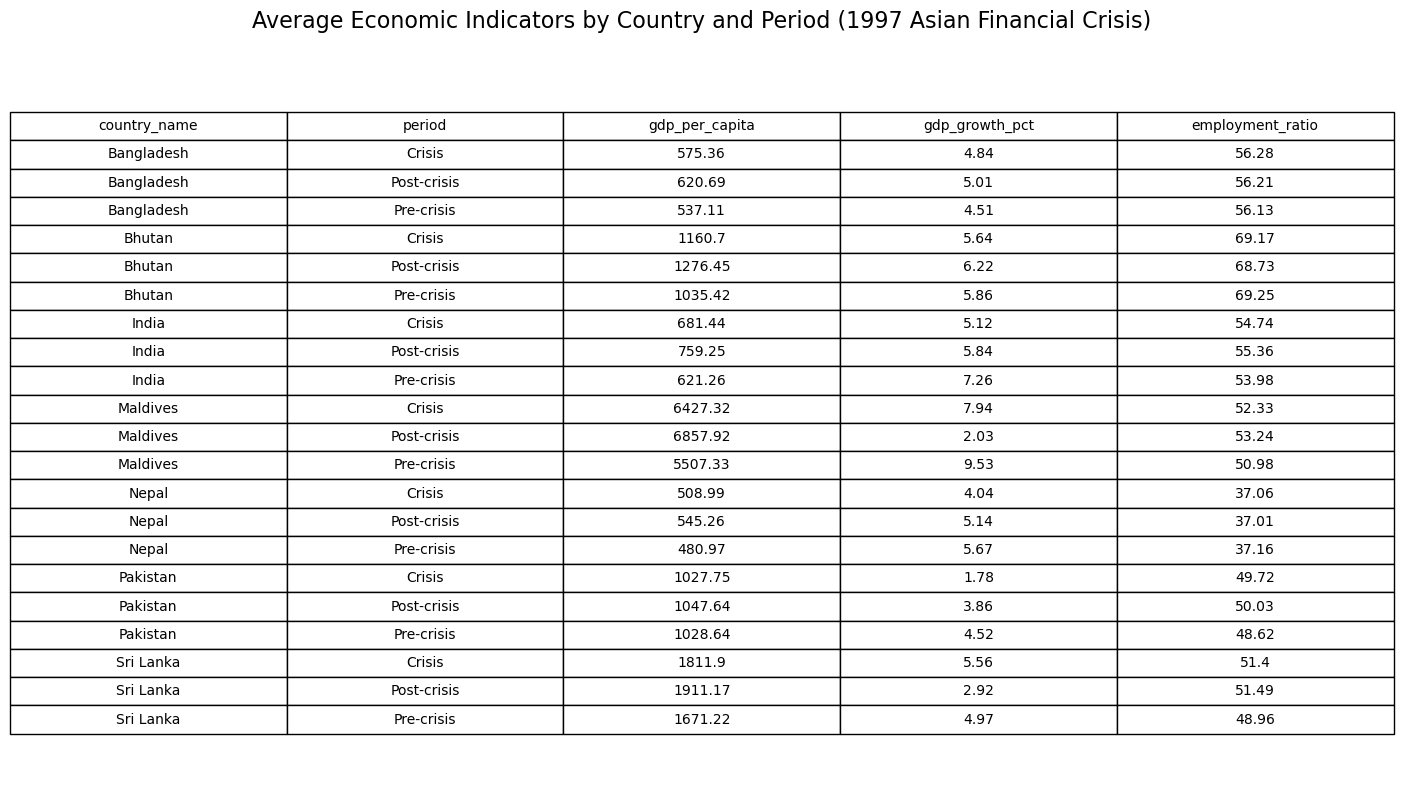

In [5]:
country_period_avg = (
    df_1997.groupby(["country_name", "period"])[["gdp_per_capita", "gdp_growth_pct", "employment_ratio"]]
    .mean()
    .round(2)
    .reset_index()
)

print("Country and Period averages")
print(country_period_avg)

fig, ax = plt.subplots(figsize=(14, 9))
ax.axis('off')

table = ax.table(
    cellText=country_period_avg.values,
    colLabels=country_period_avg.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

ax.set_title("Average Economic Indicators by Country and Period (1997 Asian Financial Crisis)", fontsize=16, pad=20)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig("../figures/country_period_avg_table_1997.png", dpi=300, bbox_inches='tight')
plt.show()

## GDP Growth

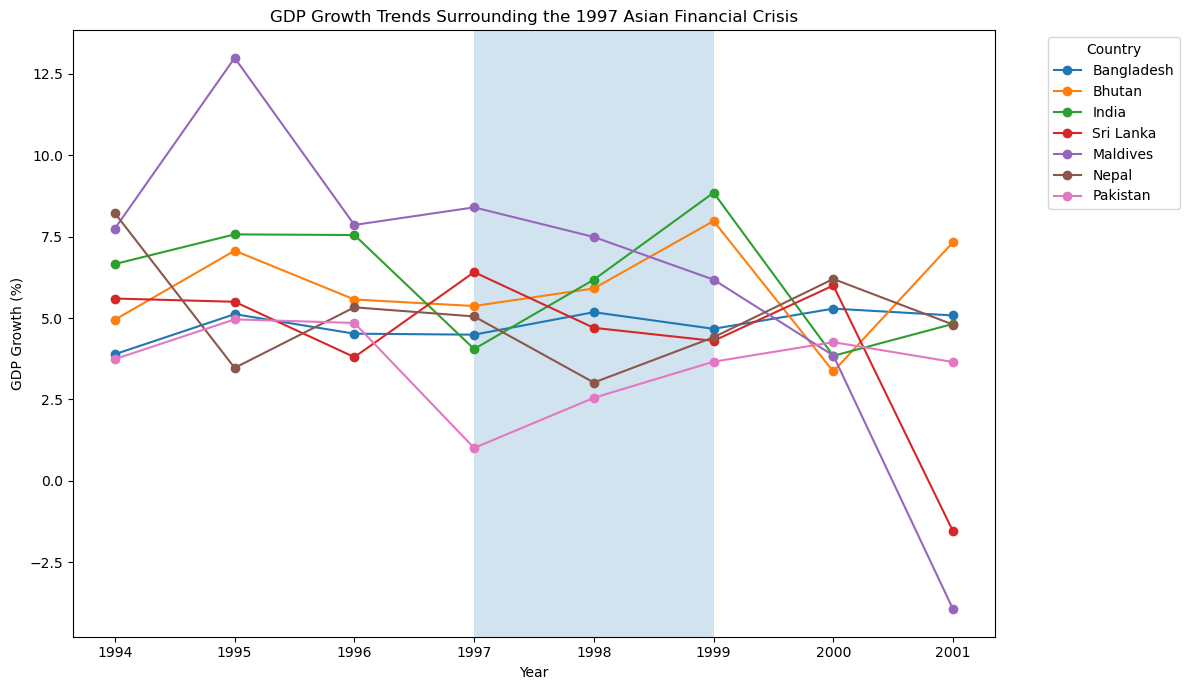

In [6]:
plt.figure(figsize=(12, 7))

for country in df_1997["country_name"].unique():
    country_data = df_1997[df_1997["country_name"] == country]
    plt.plot(
        country_data["year"],
        country_data["gdp_growth_pct"],
        marker="o",
        label=country
    )

plt.axvspan(1997, 1999, alpha=0.2)

plt.title("GDP Growth Trends Surrounding the 1997 Asian Financial Crisis")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../figures/gdp_growth_1997crisis.png", dpi=300)
plt.show()

## Employment ratio

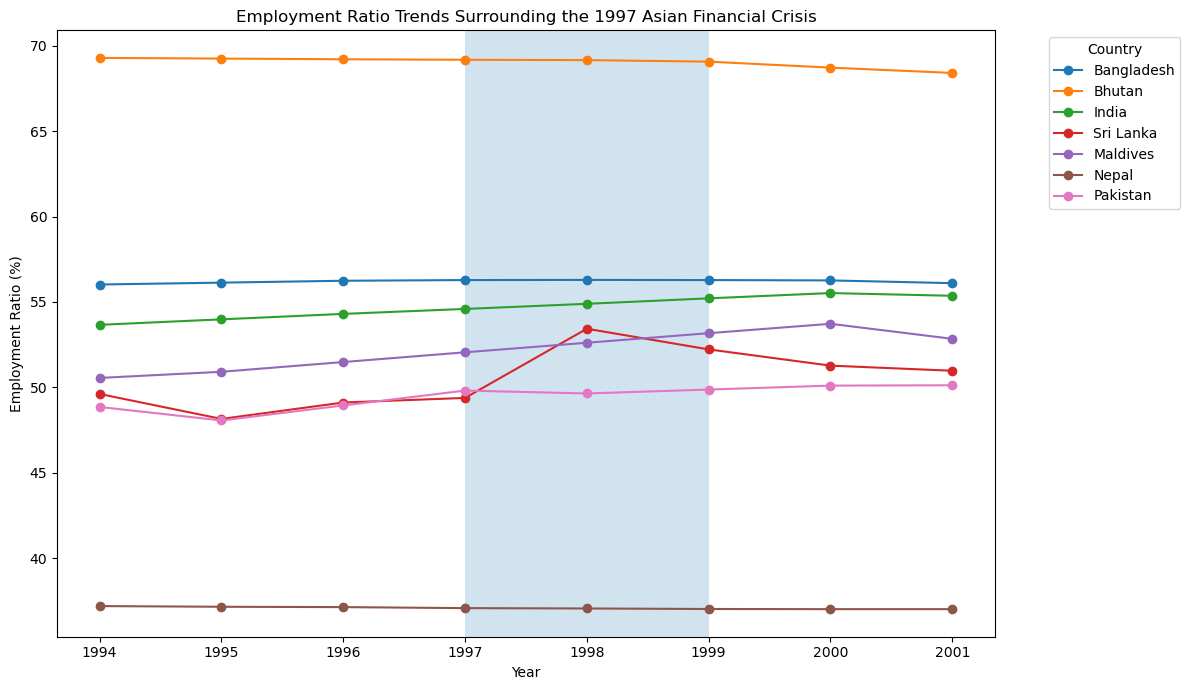

In [7]:
plt.figure(figsize=(12, 7))

for country in df_1997["country_name"].unique():
    country_data = df_1997[df_1997["country_name"] == country]
    plt.plot(country_data["year"], country_data["employment_ratio"], marker="o", label=country)

plt.axvspan(1997, 1999, alpha=0.2)

plt.title("Employment Ratio Trends Surrounding the 1997 Asian Financial Crisis")
plt.xlabel("Year")
plt.ylabel("Employment Ratio (%)")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.savefig("../figures/employment_ratio_1997crisis.png", dpi=300)
plt.tight_layout()
plt.show()

## GDP per capita

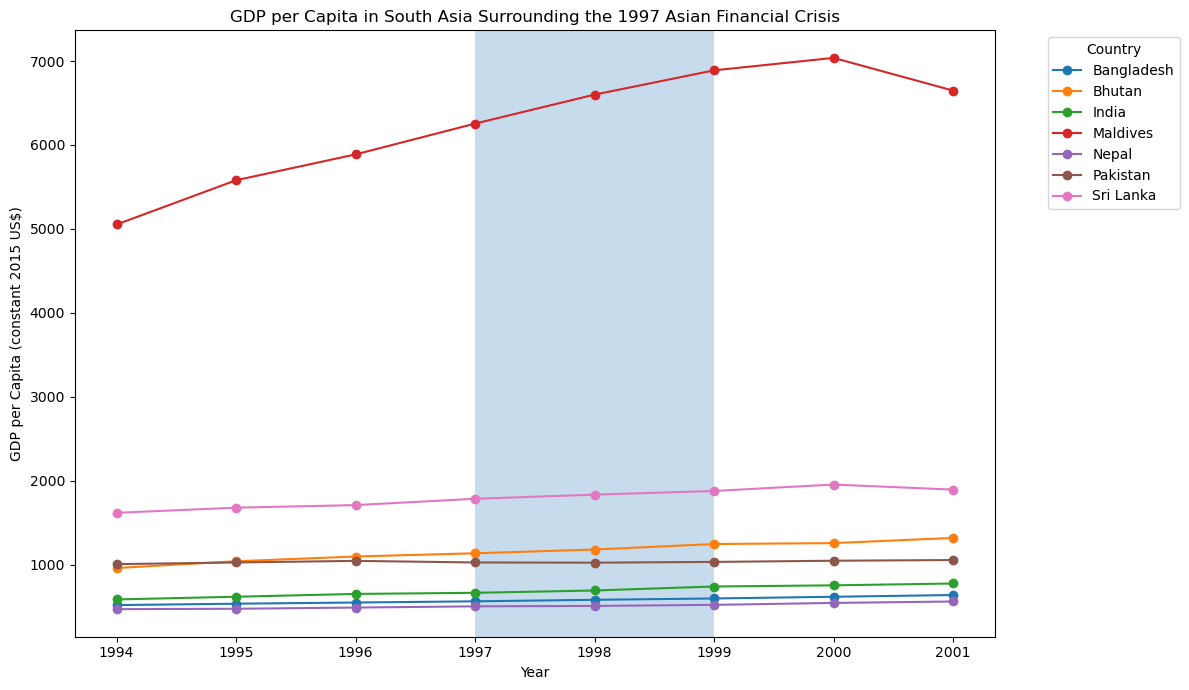

In [8]:
plt.figure(figsize=(12, 7))

for country in sorted(df_1997["country_name"].unique()):
    temp = df_1997[df_1997["country_name"] == country]
    plt.plot(temp["year"], temp["gdp_per_capita"], marker="o", label=country)

plt.axvspan(1997, 1999, alpha=0.25)

plt.title("GDP per Capita in South Asia Surrounding the 1997 Asian Financial Crisis")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (constant 2015 US$)")
plt.xticks(sorted(df_1997["year"].unique()))
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../figures/gdp_per_capita_1997crisis.png", dpi=300)
plt.show()

## Average by period

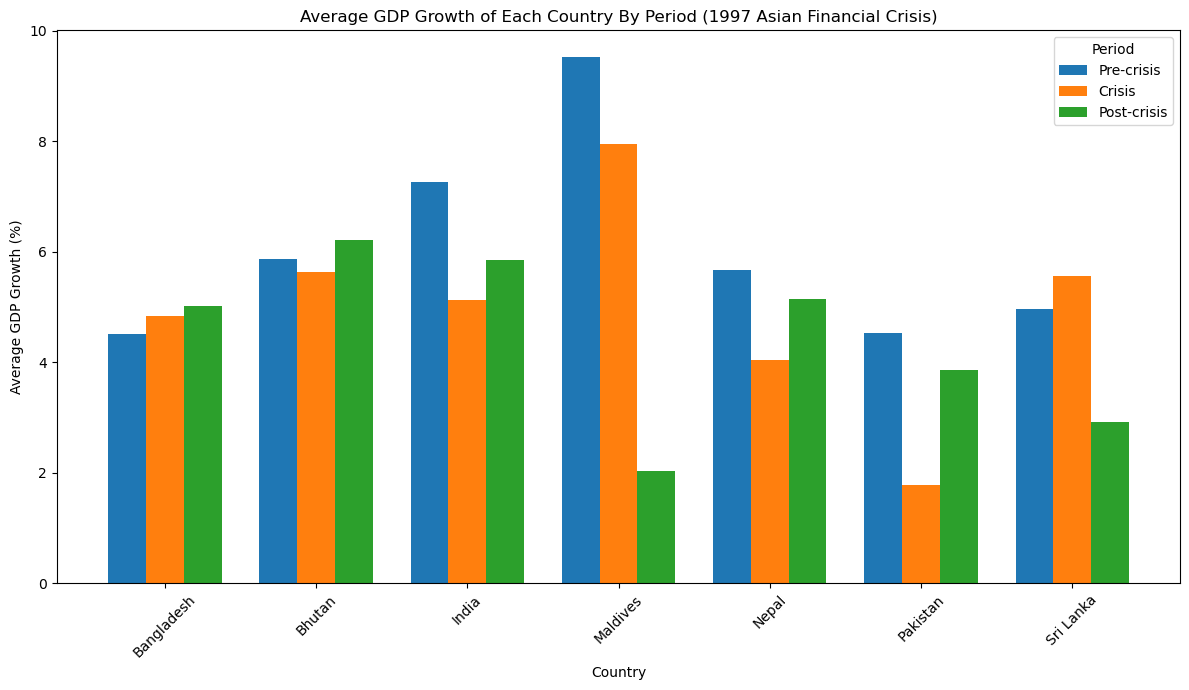

In [9]:
period_order = ["Pre-crisis", "Crisis", "Post-crisis"]

pivot_df = country_period_avg.pivot(
    index="country_name",
    columns="period",
    values="gdp_growth_pct"
)

pivot_df = pivot_df[period_order]

countries = pivot_df.index
x = np.arange(len(countries))
width = 0.25

plt.figure(figsize=(12, 7))

for i, period in enumerate(period_order):
    plt.bar(
        x + (i - 1) * width,
        pivot_df[period],
        width=width,
        label=period
    )

plt.xticks(x, countries, rotation=45)
plt.title("Average GDP Growth of Each Country By Period (1997 Asian Financial Crisis)")
plt.xlabel("Country")
plt.ylabel("Average GDP Growth (%)")
plt.legend(title="Period")
plt.tight_layout()
plt.savefig("../figures/gdp_bar_1997crisis.png", dpi=300)
plt.show()